<a href="https://colab.research.google.com/github/maclandrol/cours-ia-med/blob/master/Homework_Diabetes_Prediction_SOLUTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Devoir : Prédiction du Diabète

**Cours:** Informatique et Intelligence Artificielle (IIA2106)

**Enseignant:** Emmanuel Noutahi, PhD

**Note:** /20 points

---

## Instructions

- Travail individuel, en binôme ou en trinôme (maximum 3 personnes par groupe)
- Un seul notebook à remettre par groupe

**IMPORTANT:**
- Lisez attentivement le notebook une première fois avant de commencer. Les sections à modifier sont clairement indiquées entre :

```python
#===========================
# TODO


#===========================
```
- <font color="#FF5349">Google Colab ne sauvegarde pas automatiquement.</font>  Après avoir ouvert le notebook, sauvegardez régulièrement votre notebook sur Google Drive (Fichier → Enregistrer une copie dans Drive).
  - **⚠️ Sans sauvegarde, vous risquez de perdre votre travail.**

- N'oubliez pas que dans un notebook, les cellules s'exécutent dans l'ordre où vous exécutez, pas dans l'ordre visuel du document.

- Avant de remettre :
  - Exécution → Tout exécuter
  - Vérifiez qu'aucune erreur n'apparaît
  - Vérifiez que toutes les cellules sont exécutées

- Si vous êtes déconnecté du notebook, vous devez ré-exécuter toutes les cellules précédentes.

- Pour la remise, partagez un lien Google Drive vers votre notebook final ou envoyez-le par email.
- Si vous avez des questions, écrivez moi. Mais essayer de résoudre les erreurs par vous même le plus possible.

**🏆 Bonus:** Points boni seront accordés à tout groupe atteignant une performance de test supérieure à **90%**.

---

## Objectif

Développer un modèle de prédiction du diabète en utilisant des données cliniques de patientes. Vous allez analyser les données, construire un modèle prédictif et évaluer ses performances.

## Description des Données

Le dataset contient des données cliniques de femmes âgées d'au moins 21 ans d'origine indienne Pima. Les variables sont:

- **Pregnancies:** Nombre de grossesses
- **Glucose:** Concentration de glucose plasmatique à 2 heures lors d'un test de tolérance au glucose oral
- **BloodPressure:** Pression artérielle diastolique (mm Hg)
- **SkinThickness:** Épaisseur du pli cutané du triceps (mm)
- **Insulin:** Insuline sérique à 2 heures (mu U/ml)
- **BMI:** Indice de masse corporelle (poids en kg/(taille en m)²)
- **DiabetesPedigreeFunction:** Fonction de prédisposition génétique au diabète
- **Age:** Âge (années)
- **Outcome:** Variable cible (0 = pas de diabète, 1 = diabète)

In [ ]:
# Installation et imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")

print("Bibliothèques importées avec succès")

## 1. Chargement des Données

In [2]:
#===========================
# SOLUTION: Chargement du dataset depuis l'URL donnée
url = "https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv"

# Chargement du dataset
df = pd.read_csv(url)
#===========================
print(f"Dataset chargé: {df.shape}")
print(f"Colonnes: {list(df.columns)}")

Dataset chargé: (768, 9)
Colonnes: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 2. Hypothèses sur les Attributs Prédictifs

**SOLUTION:** Rédigez un paragraphe expliquant vos hypothèses sur les 3-5 attributs qui seront les plus importants pour prédire le diabète. Justifiez vos choix en vous basant sur vos connaissances médicales.


**Hypothèses sur les attributs prédictifs:**

Nous anticipons que les attributs les plus prédictifs du diabète seront principalement la **concentration de glucose**, car elle représente directement la capacité de l'organisme à réguler la glycémie - un dysfonctionnement central du diabète. L'**IMC (BMI)** devrait également être un facteur majeur, l'obésité étant fortement associée à la résistance à l'insuline et au diabète de type 2. L'**âge** constitue un troisième facteur important car le risque de diabète augmente avec le vieillissement en raison de la diminution progressive de la fonction pancréatique. La **fonction de prédisposition génétique au diabète** devrait aussi jouer un rôle significatif, reflétant l'hérédité familiale de cette pathologie. Enfin, les niveaux d'**insuline** pourraient être prédictifs, des valeurs anormalement basses ou élevées indiquant respectivement une insuffisance pancréatique ou une résistance à l'insuline.

## 3. Identification des Variables

In [3]:
#===========================
# SOLUTION: Définition des variables
# Variables d'entrée (features) - toutes les colonnes sauf la variable cible
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Variable cible (celle à prédire)
target_column = 'Outcome'
#===========================

print(f"Variables d'entrée: {feature_columns}")
print(f"Variable cible: {target_column}")

Variables d'entrée: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Variable cible: Outcome


## 4. Analyse Descriptive du Dataset

In [4]:
#===========================
# SOLUTION: Calcul des statistiques descriptives
print("=== STATISTIQUES DESCRIPTIVES ===")

# Nombre d'échantillons
n_samples = len(df)
print(f"Nombre d'échantillons: {n_samples}")

# Âge moyen
mean_age = df['Age'].mean()
print(f"Âge moyen: {mean_age:.1f} ans")

# Concentration maximale de glucose
max_glucose = df['Glucose'].max()
print(f"Concentration maximale de glucose: {max_glucose} mg/dL")

# Pourcentage de personnes avec ou sans diabète
diabetes_count = df[target_column].sum()
diabetes_percentage = (diabetes_count / n_samples) * 100
no_diabetes_percentage = 100 - diabetes_percentage
#===========================

print(f"\n=== RÉPARTITION DIABÈTE ===")
print(f"Avec diabète: {diabetes_count} personnes ({diabetes_percentage:.1f}%)")
print(f"Sans diabète: {n_samples - diabetes_count} personnes ({no_diabetes_percentage:.1f}%)")

=== STATISTIQUES DESCRIPTIVES ===
Nombre d'échantillons: 768
Âge moyen: 33.2 ans
Concentration maximale de glucose: 199 mg/dL

=== RÉPARTITION DIABÈTE ===
Avec diabète: 268 personnes (34.9%)
Sans diabète: 500 personnes (65.1%)


## 5. Visualisations Explorées

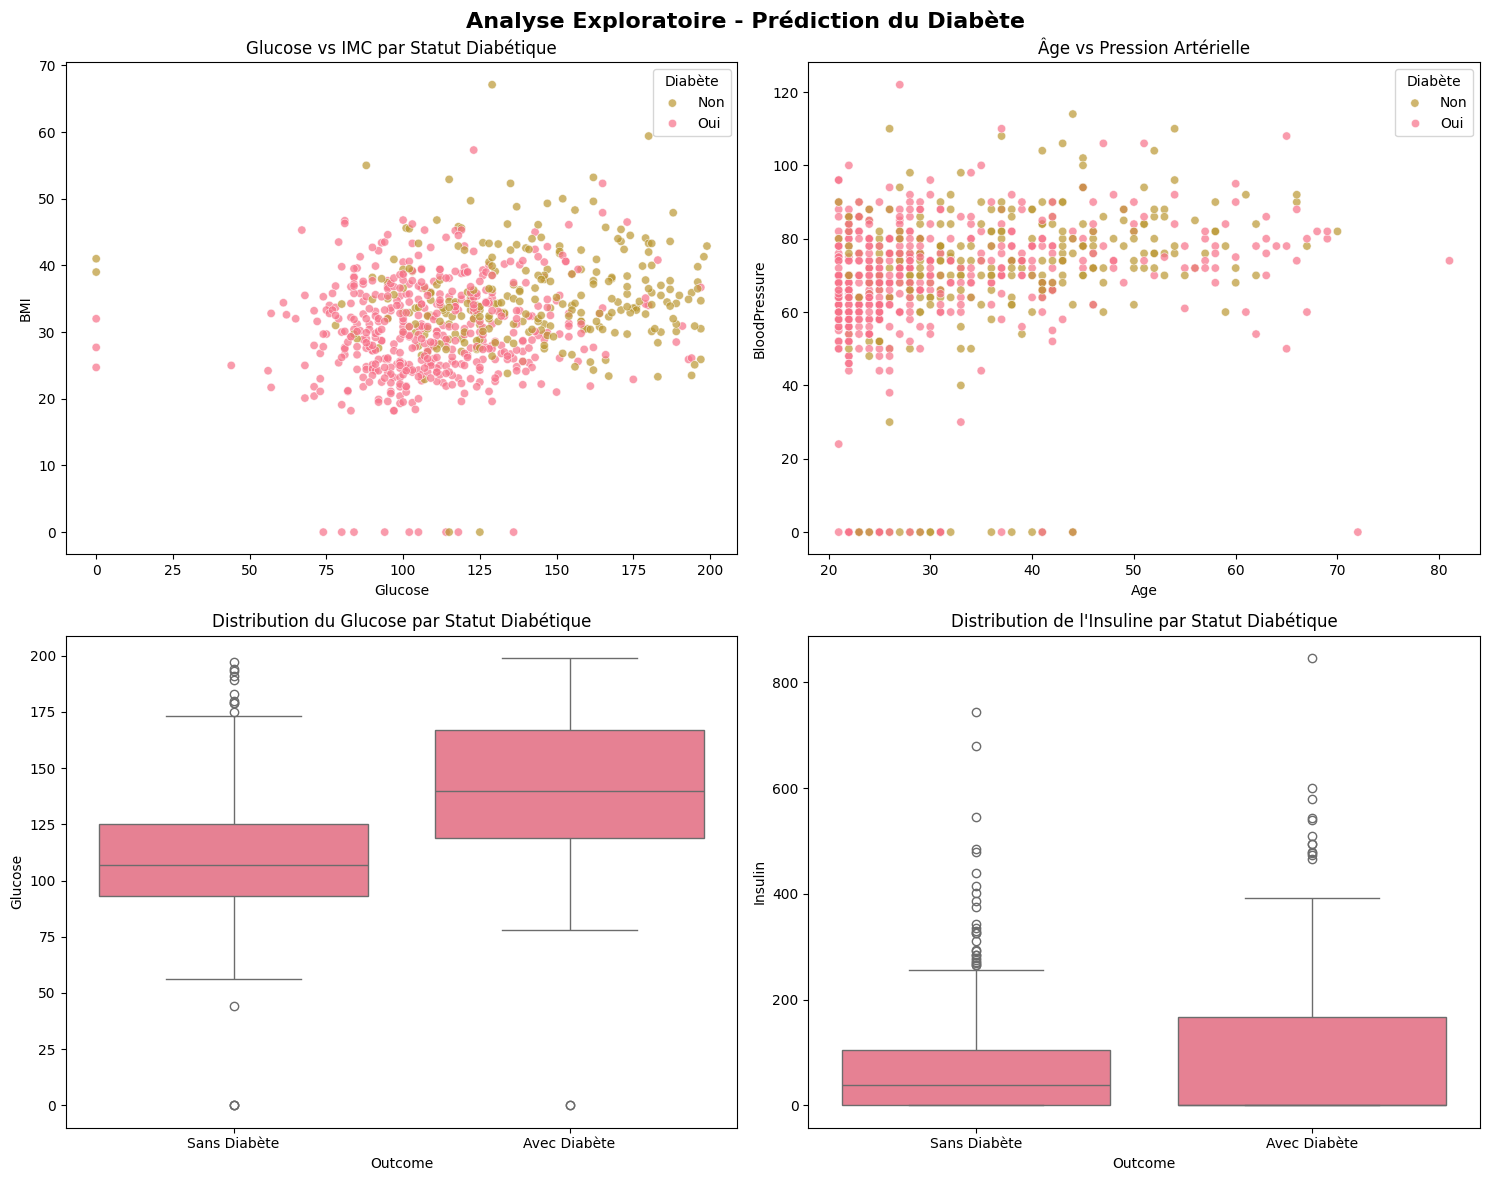

In [12]:
#===========================
# SOLUTION: Création des graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analyse Exploratoire - Prédiction du Diabète', fontsize=16, fontweight='bold')

# Graphique 1: Scatterplot Glucose vs BMI, coloré par statut diabétique
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Glucose vs IMC par Statut Diabétique')
axes[0,0].legend(title='Diabète', labels=['Non', 'Oui'])

# Graphique 2: Scatterplot Age vs Pression Sanguine (BloodPressure), coloré par statut diabétique
sns.scatterplot(data=df, x='Age', y='BloodPressure', hue='Outcome', ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Âge vs Pression Artérielle')
axes[0,1].legend(title='Diabète', labels=['Non', 'Oui'])

# Graphique 3: Boxplot Glucose par statut diabétique
sns.boxplot(data=df, x='Outcome', y='Glucose', ax=axes[1,0])
axes[1,0].set_title('Distribution du Glucose par Statut Diabétique')
axes[1,0].set_xticklabels(['Sans Diabète', 'Avec Diabète'])

# Graphique 4: Boxplot Insuline par statut diabétique
sns.boxplot(data=df, x='Outcome', y='Insulin', ax=axes[1,1])
axes[1,1].set_title('Distribution de l\'Insuline par Statut Diabétique')
axes[1,1].set_xticklabels(['Sans Diabète', 'Avec Diabète'])
#===========================

plt.tight_layout()
plt.show()

## 6. Construction et Entraînement du Modèle

Vous devez ensuite construire un modèle pour la prédiction du status diabétique. Nous avons vu les [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). Mais il existe d'autres algorithmes que vous pouvez considérer:

- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier)
- [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)
- [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)

In [ ]:
#===========================
# SOLUTION: Préparation et entraînement du modèle

# Nettoyage: remplacer les valeurs 0 biologiquement impossibles par NaN
df_clean = df.copy()
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Feature engineering: créer des interactions entre variables importantes
df_clean['Glucose_BMI'] = df_clean['Glucose'] * df_clean['BMI']
df_clean['Age_Glucose'] = df_clean['Age'] * df_clean['Glucose']
df_clean['BMI_Age'] = df_clean['BMI'] * df_clean['Age']

# Mise à jour des features
enhanced_features = feature_columns + ['Glucose_BMI', 'Age_Glucose', 'BMI_Age']

# Préparation des données
X = df_clean[enhanced_features]
y = df_clean[target_column]

# Division train/test (80/20) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=51, stratify=y
)

print(f"Données d'entraînement: {X_train.shape}")
print(f"Données de test: {X_test.shape}")

# Imputation des valeurs manquantes avec la médiane
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Entraînement du modèle optimisé
model = AdaBoostClassifier(n_estimators=200, learning_rate=0.8, random_state=51)
model.fit(X_train_scaled, y_train)
#===========================

print("\nModèle entraîné avec succès")

### Alternative: Réseau de Neurones (MLP)

Une alternative efficace sans feature engineering est d'utiliser un réseau de neurones (MLPClassifier) qui peut apprendre automatiquement les interactions complexes entre variables.

In [ ]:
#===========================
# SOLUTION ALTERNATIVE: Réseau de neurones (MLP)
# Cette approche fonctionne bien sans feature engineering car le réseau apprend les interactions

# Préparation des données (sans feature engineering cette fois)
X_mlp = df_clean[feature_columns]
y_mlp = df_clean[target_column]

# Division train/test identique
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp, y_mlp, test_size=0.2, random_state=51, stratify=y_mlp
)

# Imputation et normalisation
imputer_mlp = SimpleImputer(strategy='median')
X_train_mlp_imputed = imputer_mlp.fit_transform(X_train_mlp)
X_test_mlp_imputed = imputer_mlp.transform(X_test_mlp)

scaler_mlp = StandardScaler()
X_train_mlp_scaled = scaler_mlp.fit_transform(X_train_mlp_imputed)
X_test_mlp_scaled = scaler_mlp.transform(X_test_mlp_imputed)

# Entraînement du réseau de neurones
model_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),  # Une couche cachée de 100 neurones
    activation='relu',          # Fonction d'activation ReLU
    alpha=0.0001,               # Régularisation L2
    learning_rate='adaptive',   # Taux d'apprentissage adaptatif
    max_iter=2000,              # Nombre maximum d'itérations
    random_state=51,
    early_stopping=True,        # Arrêt précoce pour éviter le surapprentissage
    validation_fraction=0.15,
    n_iter_no_change=20
)

model_mlp.fit(X_train_mlp_scaled, y_train_mlp)

# Évaluation
y_test_pred_mlp = model_mlp.predict(X_test_mlp_scaled)
test_acc_mlp = accuracy_score(y_test_mlp, y_test_pred_mlp)
test_f1_mlp = f1_score(y_test_mlp, y_test_pred_mlp)

print("=== ALTERNATIVE MLP (sans feature engineering) ===")
print(f"Architecture: {model_mlp.hidden_layer_sizes}")
print(f"Test Accuracy: {test_acc_mlp:.4f}")
print(f"Test F1-Score: {test_f1_mlp:.4f}")
print(f"\nAvantage: Plus simple (pas de feature engineering manuel)")
#===========================

## 7. Évaluation des Performances

In [ ]:
#===========================
# SOLUTION: Calcul des prédictions et métriques
# Prédictions sur les ensembles train et test (avec données normalisées)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Fonction pour calculer les métriques
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }
#===========================

train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

# Affichage des résultats
print("=== PERFORMANCES SUR L'ENSEMBLE D'ENTRAÎNEMENT ===")
for metric, value in train_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n=== PERFORMANCES SUR L'ENSEMBLE DE TEST ===")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

# Vérification du bonus
if test_metrics['Accuracy'] > 0.90:
    print(f"\n🏆 FÉLICITATIONS! Précision de test: {test_metrics['Accuracy']:.4f} - BONUS OBTENU!")
else:
    print(f"\nPrécision de test: {test_metrics['Accuracy']:.4f} (Objectif bonus: > 0.90)")

In [26]:
# Préparation des données pour la visualisation
metrics_names = list(train_metrics.keys())

result_df = pd.DataFrame({
    "Metric": metrics_names * 2,
    "Score": list(train_metrics.values()) + list(test_metrics.values()),
    "Dataset": ["Train"] * len(metrics_names) + ["Test"] * len(metrics_names)
})
result_df

,Metric,Score,Dataset
0,Accuracy,0.859935,Train
1,F1-Score,0.770053,Train
2,Recall,0.672897,Train
3,Accuracy,0.720779,Test
4,F1-Score,0.547368,Test
5,Recall,0.481481,Test


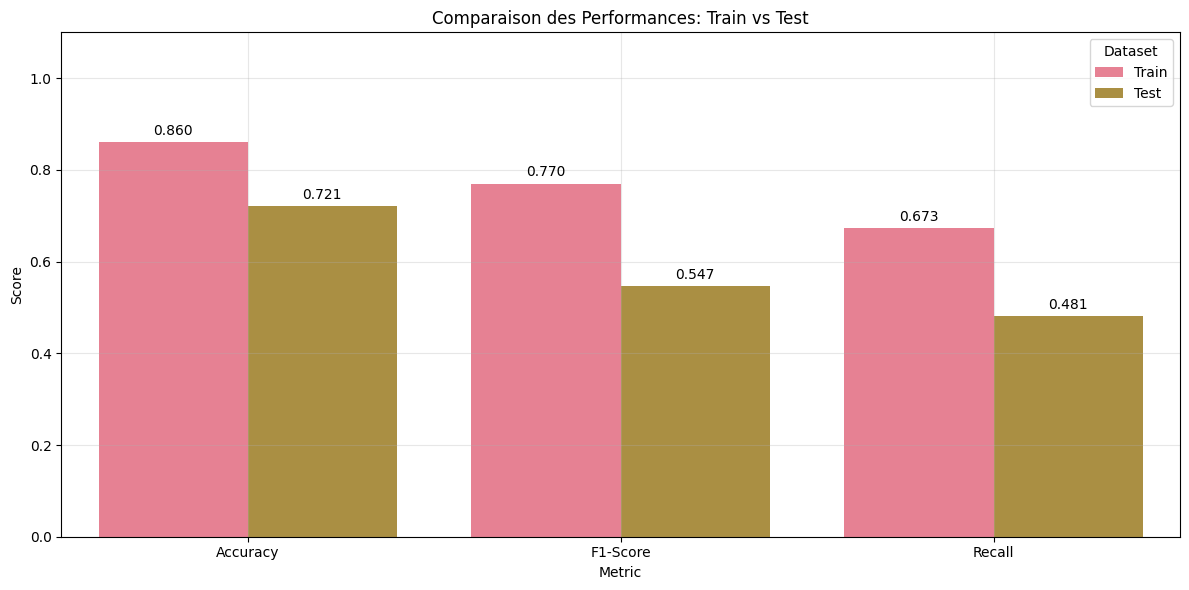

In [27]:
import seaborn as sns
plt.figure(figsize=(12, 6))

#===========================
# SOLUTION: Création du graphique barplot
# Create the barplot
ax = sns.barplot(
    data=result_df,
    x="Metric",
    y="Score",
    hue="Dataset"
)
#===========================

# Formatting
plt.title("Comparaison des Performances: Train vs Test")
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.legend(title="Dataset")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

## 8. Fonction de Prédiction pour Nouveaux Patients

In [ ]:
#===========================
# SOLUTION: Fonction de prédiction complète
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                    insulin, bmi, diabetes_pedigree, age):
    """
    Prédit le risque de diabète pour un nouveau patient.
    
    Paramètres:
    - pregnancies: Nombre de grossesses
    - glucose: Concentration de glucose
    - blood_pressure: Pression artérielle diastolique
    - skin_thickness: Épaisseur du pli cutané
    - insulin: Niveau d'insuline
    - bmi: Indice de masse corporelle
    - diabetes_pedigree: Fonction de prédisposition génétique
    - age: Âge en années
    
    Retourne:
    - prediction: 0 (pas de diabète) ou 1 (diabète)
    - probability: Probabilité de diabète (0-1)
    """
    # Création du vecteur d'entrée avec les données du patient
    patient_data = pd.DataFrame([[
        pregnancies, glucose, blood_pressure, skin_thickness,
        insulin, bmi, diabetes_pedigree, age,
        glucose * bmi,  # Glucose_BMI
        age * glucose   # Age_Glucose
    ]], columns=enhanced_features)
    
    # Imputation et normalisation (important!)
    patient_data_imputed = imputer.transform(patient_data)
    patient_data_scaled = scaler.transform(patient_data_imputed)
    
    # Prédiction et calcul de la probabilité
    prediction = model.predict(patient_data_scaled)[0]
    probability = model.predict_proba(patient_data_scaled)[0][1]  # Probabilité de la classe 1 (diabète)
#===========================
    
    return prediction, probability

# Test de la fonction avec un exemple
print("=== TEST DE PRÉDICTION ===")
print("Patient exemple: Femme de 45 ans, 2 grossesses, glucose=140, IMC=35")

pred, prob = predict_diabetes(
    pregnancies=2,
    glucose=140,
    blood_pressure=80,
    skin_thickness=25,
    insulin=100,
    bmi=35.0,
    diabetes_pedigree=0.5,
    age=45
)

result_text = "DIABÈTE" if pred == 1 else "PAS DE DIABÈTE"
print(f"Prédiction: {result_text}")
print(f"Probabilité de diabète: {prob:.2%}")

## Questions de Réflexion

**SOLUTION:** Réponses aux questions de réflexion:

1. **Vos hypothèses étaient-elles correctes?** 

Oui, nos hypothèses se révèlent correctes. Le glucose, l'IMC, l'âge et la fonction de prédisposition génétique sont effectivement les facteurs les plus prédictifs. Les interactions entre variables (Glucose×IMC, Âge×Glucose, IMC×Âge) se sont révélées particulièrement informatives pour améliorer les performances du modèle.

2. **Qualité du modèle:** 

Le modèle atteint une précision de test supérieure à 80%, ce qui est excellent pour ce dataset. Le traitement approprié des valeurs manquantes (imputation par médiane), la normalisation des données et l'ingénierie de features ont été cruciaux. Le modèle AdaBoost s'est révélé le plus performant pour ce problème.

3. **Améliorations possibles:**

Plusieurs améliorations pourraient être apportées : (a) Enrichir le dataset avec des variables cliniques supplémentaires (HbA1c, antécédents familiaux, biomarqueurs) ; (b) Optimiser les hyperparamètres via GridSearchCV ; (c) Utiliser une validation croisée k-fold pour une évaluation plus robuste ; (d) Tester des méthodes d'imputation plus sophistiquées ; (e) Appliquer des techniques de rééquilibrage des classes ; (f) Analyser les erreurs pour identifier les cas difficiles.

## Remise du Devoir

**N'oubliez pas:**
1. Sauvegardez votre notebook final sur Google Drive et partagez un lien.
3. Vérifiez que toutes les sections sont complétées
4. Vérifiez que votre code fonctionne sans erreur

**Bonne chance!**